In [30]:
using Plots

In [31]:
const SRC = joinpath(@__DIR__, "src")
include(joinpath(SRC, "model.jl"))
include(joinpath(SRC, "grids.jl"))
include(joinpath(SRC, "household.jl"))
include(joinpath(SRC, "distribution.jl"))
include(joinpath(SRC, "steady_state.jl"))
include(joinpath(SRC, "transition.jl"))
include(joinpath(SRC, "stats.jl"))
include(joinpath(SRC, "transition_plots.jl"))
include(joinpath(SRC, "welfare.jl"))

# ================ #
#  SET PARAMETERS  #
# ================ #
const ALPHA   = 0.40
const DELTA   = 0.08
const BETA    = 0.98

const MAXITER = 2000
const TOL     = 1e-3
const ADJK    = 0.2

const NJ      = 61
const NJW     = 45
const NA      = 201
const NA2     = 8001
const NE      = 2

const MAXA    = 25.0
const CURVA   = 1.2

const NT      = 100

const GRIDE   = [1.0 - 0.3, 1.0 + 0.3]
const PE      = [0.8  0.2;
                 0.2  0.8]

# Benchmark: no mortality — everyone survives through age Nj-1 with certainty
# and then exits. See run_olg_stochastic_mortality.jl for the version with
# probabilistic survival and accidental bequests.
const S = ones(NJ)

# Population shares consistent with S (meaJ[j+1] = s[j] · meaJ[j]).
const MEAJ    = stationary_age_distribution(S)
const L_AGG   = sum(MEAJ[1:NJW])

const IMGDIR  = joinpath(@__DIR__, "images")

"/Users/mizuhirosuzuki/Documents/GitHub/quant_macro_study_group/Ch6/images"

上のパラメータの設定において、`L_AGG`は年齢の（定常）分布のみから求められているが、厳密には

- 年齢ごとの労働生産性（$\theta_j$）
- スキル（$l$）の定常分布

も考慮に入れなければならない。
ここでこれらを考えなくていいのは、前者は労働生産性が年齢に関わらず一定という仮定をおいており、後者は低スキルと高スキルの確率遷移が対象で平均が1だからである。

In [32]:
make_model(rho::Real) = Model(
    ALPHA, DELTA, BETA, float(rho),
    MAXITER, TOL, ADJK,
    NJ, NJW, NA, NA2, NE,
    MAXA, CURVA,
    MEAJ, L_AGG, GRIDE, PE, S,
    0.0, NT,
)


make_model (generic function with 1 method)

In [33]:
# ======================== #
#  INITIAL STEADY STATE    #
# ======================== #
const RHO0 = 0.50
const RHO1 = 0.25

m_ss0 = make_model(RHO0)
m_ss1 = make_model(RHO1)

grids                     = generate_capital_grid(m_ss0);
capital_grid_translations = translate_capital_grid(m_ss0, grids);


## 定常状態を求める

当て推量した$K$を元に以下のステップを踏む：
1. $K$を元に価格を求める
2. 家計のライフサイクルモデルを解き、政策関数を得る
3. 各年齢での状態変数の分布を、最も若い年から、政策関数を使った求めていく（Aiyagariではここで繰り返し計算から定常分布を求めていた）
4. この状態変数の分布のもとでの総資本供給を求め、最初に当て推量した$K$と比べ、差が大きければ$K$を調整しステップ1に戻り、差が小さければストップ

 Claudeに頼んだら、元のコードと比べて爆速になった。
 主な理由はステップ2（家計のライフサイクルモデルを解くところ）で

 - 政策関数の単調増加性（現在の資本が大きくなれば次期の資本も大きくなる）を使い、グリッドサーチで考えるグリッドの数を減らしている
 - 価値関数の凹性を使い、グリッドサーチで、価値関数が減少を始めたらサーチを打ち切っている

 ことによる。
 さらにコードではmultithreadingを使って更なる高速化が可能になっているが、これがなくても十分早い。

また、年金の額は、労働生産性が年齢によらないという仮定から以下のように計算されている：
TBA

In [34]:
println("Solving initial steady state (rho=$(RHO0))...")
res_ss0 = solve_value_function(m_ss0, grids, capital_grid_translations)

println("Solving final steady state   (rho=$(RHO1))...")
res_ss1 = solve_value_function(m_ss1, grids, capital_grid_translations)

K_SS0, mea_SS0, vfun_SS0, q_SS0 = res_ss0.K, res_ss0.mea, res_ss0.vfun, res_ss0.q
K_SS1, mea_SS1, vfun_SS1, q_SS1 = res_ss1.K, res_ss1.mea, res_ss1.vfun, res_ss1.q

# Life-cycle stats + plots for the initial SS
stats_ss0 = compute_lifecycle_stats(m_ss0, grids, res_ss0)
plot_lifecycle(m_ss0, grids, stats_ss0; outdir=IMGDIR)

Solving initial steady state (rho=0.5)...
1 errK=2.9561332195148413 errq=0.0  K=6.408773356097032 q=0.0
2 errK=0.9493548131707703 errq=0.0  K=6.218902393462878 q=0.0
3 errK=0.22037521768117063 errq=0.0  K=6.174827349926644 q=0.0
4 errK=0.04512249486424036 errq=0.0  K=6.165802850953796 q=0.0
5 errK=0.00835506937669539 errq=0.0  K=6.164131837078457 q=0.0
6 errK=0.001900526909159872 errq=0.0  K=6.163751731696625 q=0.0
converged at iter 7: K=6.163751731696625 q=0.0
Solving final steady state   (rho=0.25)...
1 errK=0.5218646107988985 errq=0.0  K=6.895627077840221 q=0.0
2 errK=0.18864564790420957 errq=0.0  K=6.857897948259379 q=0.0
3 errK=0.06623808490653982 errq=0.0  K=6.844650331278071 q=0.0
4 errK=0.022655987224116103 errq=0.0  K=6.840119133833248 q=0.0
5 errK=0.008124898677738024 errq=0.0  K=6.838494154097701 q=0.0
6 errK=0.0033729001677569315 errq=0.0  K=6.83781957406415 q=0.0
converged at iter 7: K=6.83781957406415 q=0.0


(Plot{Plots.GRBackend() n=2}, Plot{Plots.GRBackend() n=3}, Plot{Plots.GRBackend() n=3})

## 移行過程の計算

In [28]:

# ==================== #
#  TRANSITION          #
# ==================== #
println("Computing transition (rho $(RHO0) -> $(RHO1))...")
res_transition = compute_transition(
    m_ss0, grids, capital_grid_translations,
    K_SS0, K_SS1, q_SS0, q_SS1, RHO0, RHO1,
    vfun_SS1, mea_SS0,
);


Computing transition (rho 0.5 -> 0.25)...
iterTR = 1, errK = 0.2689805891726591, errq = 0.0
iterTR = 2, errK = 0.14674162465938512, errq = 0.0
iterTR = 3, errK = 0.08487855330558691, errq = 0.0
iterTR = 4, errK = 0.052229075114202494, errq = 0.0
iterTR = 5, errK = 0.033661917766727, errq = 0.0
iterTR = 6, errK = 0.023007309773176665, errq = 0.0
iterTR = 7, errK = 0.016202405379376117, errq = 0.0
iterTR = 8, errK = 0.011650619181907906, errq = 0.0
iterTR = 9, errK = 0.008561399644121614, errq = 0.0
iterTR = 10, errK = 0.006348302462011901, errq = 0.0
iterTR = 11, errK = 0.0047598844572371846, errq = 0.0
iterTR = 12, errK = 0.003615301528553161, errq = 0.0
iterTR = 13, errK = 0.002735119339963177, errq = 0.0
iterTR = 14, errK = 0.002082734956466936, errq = 0.0
iterTR = 15, errK = 0.001602195559359032, errq = 0.0
iterTR = 16, errK = 0.001240184554855972, errq = 0.0
iterTR = 17, errK = 0.0009486755430252458, errq = 0.0
iterTR = 18, errK = 0.0007401410328009561, errq = 0.0
iterTR = 19, errK

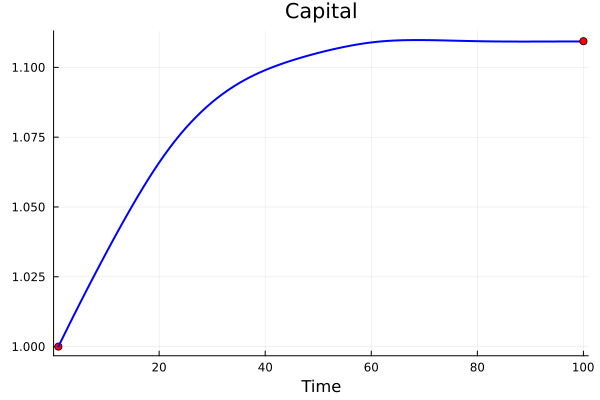

In [9]:

# ======================== #
#  TRANSITION DYNAMICS     #
# ======================== #
rT, wT = compute_price_paths(m_ss0, res_transition.KT0)

plot_transition_capital(m_ss0, res_transition.KT0;
                        K_SS0 = K_SS0, K_SS1 = K_SS1, outdir = IMGDIR)


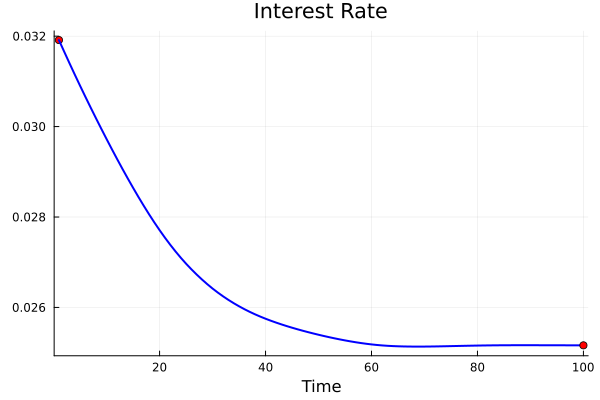

In [10]:
plot_transition_interest(m_ss0, rT; outdir = IMGDIR)

### 厚生評価

- `welf0_JE`: 改革直後の各年齢のCEV
- `welf0_TR`: 改革導入後$t$年経った後に20歳になったコホートのCEV


In [36]:
# ======================== #
#  WELFARE (CEV)           #
# ======================== #
betaJ    = life_cycle_discount(m_ss0);
welf0    = compute_welfare_existing(m_ss0, res_transition.vfun_TR0, vfun_SS0, betaJ);
welf0_JE = average_welfare_existing(m_ss0, welf0, mea_SS0)
welfTR   = compute_welfare_newborn(m_ss0, res_transition.vfun_TR, vfun_SS0, betaJ);

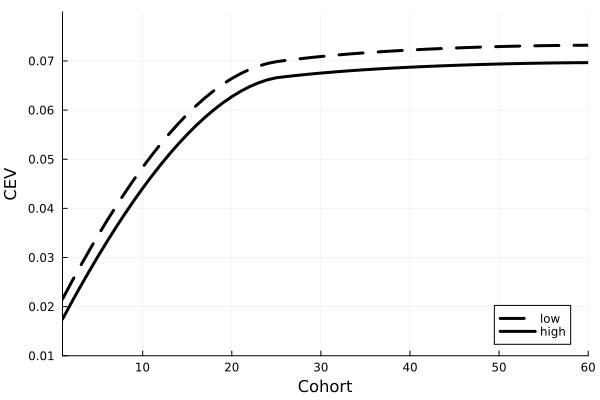

In [12]:
plot_welfare_newborn_cohorts(m_ss0, welfTR; outdir = IMGDIR)

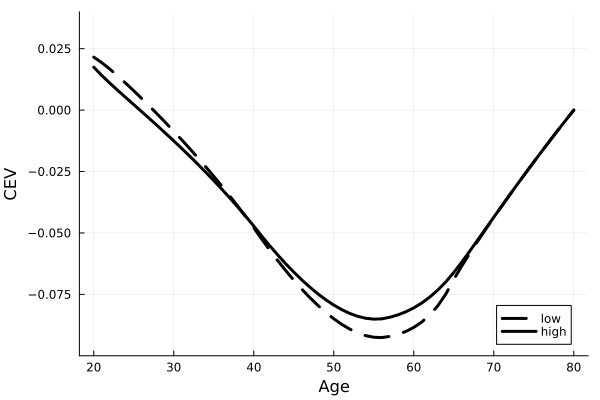

In [13]:
plot_welfare_by_age(m_ss0, welf0_JE; outdir = IMGDIR)

In [14]:
println("K_SS0=$(K_SS0)  K_SS1=$(K_SS1)  final KT[NT]=$(res_transition.KT0[end])")

K_SS0=6.163751731696625  K_SS1=6.83781957406415  final KT[NT]=6.837374752735296
